In [30]:
!python -m pip install pandas numpy scikit-learn xgboost lightgbm catboost matplotlib

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
    --------------------------------------- 2.1/100.2 MB 11.3 MB/s eta 0:00:09
   -- ------------------------------------- 5.8/100.2 MB 14.9 MB/s eta 0:00:07
   ---- ----------------------------------- 11.5/100.2 MB 19.4 MB/s eta 0:00:05
   ------ --------------------------------- 17.3/100.2 MB 21.9 MB/s eta 0:00:04
   ---------- ----------------------------- 25.2/100.2 MB 25.2 MB/s eta 0:00:03
   ------------ --------------------------- 31.7/100.2 MB 26.8 MB/s eta 0:00:03
   ------------- -------------------------- 34.6/100.2 MB 24.7 MB/s eta 0:00:03
   -------------- ------------------------- 37.2/100.2 MB 23.1 MB/s eta 0:00:03
   --------------- ------------------------ 39.3/100.2 MB 21.8 MB/s et

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# %% [1] Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

# Model Architectures
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Standard libraries and ML frameworks imported successfully.")

Standard libraries and ML frameworks imported successfully.


In [ ]:
os.environ["KAGGLE_USERNAME"] = ""
os.environ["KAGGLE_KEY"] = ""

In [ ]:
# %% [2] Load Dataset from Kaggle & Save to Local Folder
import os
import shutil
import kagglehub
import pandas as pd

# 1. Ambil path lokal tempat kagglehub menyimpan data cache
local_folder_path = kagglehub.dataset_download("raphaelnazareth/indonesia-financial-time-series-dataset-2010-2026")

# 2. Definisikan nama file dan path lengkap sumbernya
csv_file_name = "Daily Multi-Asset Macroeconomic and Financial Time Series Dataset (IndonesiaGlobal Markets).csv"
full_csv_path = os.path.join(local_folder_path, csv_file_name)

# 3. Tentukan path tujuan di folder kerja saat ini (Local Directory)
local_destination_path = os.path.join(os.getcwd(), csv_file_name)

# 4. Salin file dari folder cache kagglehub ke folder proyek saat ini
if not os.path.exists(local_destination_path):
    shutil.copy(full_csv_path, local_destination_path)
    print(f"File berhasil disalin dan disimpan secara lokal di: {local_destination_path}")
else:
    print("File sudah ada di folder lokal, melewati proses penyalinan.")

# 5. Baca file CSV dari folder lokal ke dalam DataFrame
df = pd.read_csv(local_destination_path)

print("\nDataset loaded successfully!")
print(df.head())
print(f"Dataset berhasil dimuat. Total records awal: {df.shape[0]} baris, {df.shape[1]} kolom.")

File berhasil disalin dan disimpan secara lokal di: c:\Users\IT-DEV2\OneDrive\Documents\jurnal\Daily Multi-Asset Macroeconomic and Financial Time Series Dataset (IndonesiaGlobal Markets).csv

Dataset loaded successfully!
         Date        OIL         GOLD       USDIDR        SP500         IHSG  \
0  2010-01-01        NaN          NaN  9385.599609          NaN          NaN   
1  2010-01-04  81.510002  1117.699951  9364.200195  1132.989990  2575.312988   
2  2010-01-05  81.769997  1118.099976  9305.200195  1136.520020  2605.175537   
3  2010-01-06  83.180000  1135.900024  9218.099609  1137.140015  2603.195557   
4  2010-01-07  82.660004  1133.099976  9272.500000  1141.689941  2586.794189   

         VIX       CPI  BI_rate  US_rate  
0        NaN  5.134206      6.5     0.11  
1  20.040001  5.134206      6.5     0.11  
2  19.350000  5.134206      6.5     0.11  
3  19.160000  5.134206      6.5     0.11  
4  19.059999  5.134206      6.5     0.11  
Dataset berhasil dimuat. Total records a

In [57]:
# %% [3] Data Preprocessing & Log Return Transformation
# 1. Konversi format kolom tanggal
df['Date'] = pd.to_datetime(df['Date'])

# 2. Set Date sebagai index dan urutkan secara kronologis (Sangat krusial untuk Time-Series)
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# 3. Menangani Missing Values akibat libur bursa (Forward Fill diikuti Backward Fill)
df = df.ffill().bfill()

# 4. Transformasi seluruh dataframe ke bentuk Log Return agar data bersifat STASIONER
df_return = np.log(df / df.shift(1))
print("Preprocessing & Transformasi Log Return selesai. Data bebas dari NaN.")

print(df.head())

Preprocessing & Transformasi Log Return selesai. Data bebas dari NaN.
                  OIL         GOLD       USDIDR        SP500         IHSG  \
Date                                                                        
2010-01-01  81.510002  1117.699951  9385.599609  1132.989990  2575.312988   
2010-01-04  81.510002  1117.699951  9364.200195  1132.989990  2575.312988   
2010-01-05  81.769997  1118.099976  9305.200195  1136.520020  2605.175537   
2010-01-06  83.180000  1135.900024  9218.099609  1137.140015  2603.195557   
2010-01-07  82.660004  1133.099976  9272.500000  1141.689941  2586.794189   

                  VIX       CPI  BI_rate  US_rate  
Date                                               
2010-01-01  20.040001  5.134206      6.5     0.11  
2010-01-04  20.040001  5.134206      6.5     0.11  
2010-01-05  19.350000  5.134206      6.5     0.11  
2010-01-06  19.160000  5.134206      6.5     0.11  
2010-01-07  19.059999  5.134206      6.5     0.11  


c:\Users\IT-DEV2\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [5]:
# %% [4] Multi-Lag Feature Engineering Berbasis Return
features_to_lag = ['IHSG', 'USDIDR', 'SP500', 'GOLD', 'OIL', 'VIX']
lags = [1, 2, 3, 5, 10]

# Membuat DataFrame baru khusus untuk modeling struktur return
df_model = pd.DataFrame(index=df.index)

# Jadikan Return IHSG hari ini sebagai baseline t0
for col in features_to_lag:
    df_model[f'{col}_return_t0'] = df_return[col]

# Membuat fitur multi-lag per variabel makro
print("Membuat fitur multi-lag...")
for col in features_to_lag:
    for lag in lags:
        df_model[f'{col}_lag_{lag}'] = df_return[col].shift(lag)

# Hapus baris awal yang bernilai NaN akibat pergeseran baris (shift) & log return pertama
df_model.dropna(inplace=True)
print(f"Feature engineering selesai. Total fitur sekarang: {df_model.shape[1]} kolom.")

Membuat fitur multi-lag...
Feature engineering selesai. Total fitur sekarang: 36 kolom.


In [6]:
# %% [5] Labeling / Menentukan Target Prediksi (Log Return Esok Hari)
# Target kita adalah memprediksi nilai Log Return IHSG untuk 1 hari ke depan (t+1)
df_model['Target_IHSG_Return'] = df_model['IHSG_return_t0'].shift(-1)

# Hapus baris terakhir karena tidak memiliki nilai target masa depan
df_model.dropna(inplace=True)

# Pisahkan Fitur (X) dan Target (y)
X = df_model.drop(columns=['Target_IHSG_Return'])
y = df_model['Target_IHSG_Return']

In [7]:
# %% [6] Chronological Time-Series Split (Mencegah Data Leakage)
# Menggunakan proporsi 80% Training dan 20% Testing secara berurutan
split_idx = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Split Data Berhasil:")
print(f"- Training Data : {X_train.index.min()} s/d {X_train.index.max()} ({len(X_train)} sampel)")
print(f"- Testing Data  : {X_test.index.min()} s/d {X_test.index.max()} ({len(X_test)} sampel)")

Split Data Berhasil:
- Training Data : 2010-01-18 00:00:00 s/d 2023-02-15 00:00:00 (3404 sampel)
- Testing Data  : 2023-02-16 00:00:00 s/d 2026-05-28 00:00:00 (852 sampel)


In [8]:
# mencari hyperparameter terbaik untuk setiap model menggunakan GridSearchCV dengan TimeSeriesSplit
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import pandas as pd

# 1. Definisikan TimeSeriesSplit (Misal: 3 lipatan bursa berurutan)
tscv = TimeSeriesSplit(n_splits=3)

# 2. Definisikan Ruang Parameter (Parameter Grid) untuk Masing-Masing Model
param_grids = {
    'XGBoost': {
        'model': xgb.XGBRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [500, 1000],
            'learning_rate': [0.03, 0.1],
            'max_depth': [4, 6]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        'params': {
            'n_estimators': [500, 1000],
            'learning_rate': [0.03, 0.1],
            'num_leaves': [31, 63]
        }
    },
    'CatBoost': {
        'model': CatBoostRegressor(random_state=42, verbose=0),
        'params': {
            'iterations': [500, 1000],
            'learning_rate': [0.03, 0.1],
            'depth': [4, 6]
        }
    }
}

# 3. Looping Tuning untuk Setiap Arsitektur
best_models = {}

print("=== MEMULAI HYPERPARAMETER TUNING SECARA KRONOLOGIS ===\n")

for name, config in param_grids.items():
    print(f"Mengoptimalkan {name}...")
    
    # Inisialisasi GridSearchCV dengan Cross-Validation Khusus Waktu
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=tscv,
        scoring='neg_mean_squared_error', # Meminimalkan MSE
        n_jobs=-1
    )
    
    # Proses pencarian kombinasi terbaik menggunakan data training
    grid_search.fit(X_train, y_train)
    
    # Simpan model terbaik yang sudah di-tuning
    best_models[name] = grid_search.best_estimator_
    
    print(f"-> Parameter Terbaik {name}: {grid_search.best_params_}\n")

print("=== TUNING SELESAI ===")

=== MEMULAI HYPERPARAMETER TUNING SECARA KRONOLOGIS ===

Mengoptimalkan XGBoost...
-> Parameter Terbaik XGBoost: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 500}

Mengoptimalkan LightGBM...
-> Parameter Terbaik LightGBM: {'learning_rate': 0.03, 'n_estimators': 500, 'num_leaves': 63}

Mengoptimalkan CatBoost...
-> Parameter Terbaik CatBoost: {'depth': 6, 'iterations': 500, 'learning_rate': 0.03}

=== TUNING SELESAI ===


In [9]:
# %% [7] Model Training & Architectures Comparison
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}
predictions = {}

print("\nMemulai proses evaluasi menggunakan arsitektur hasil tuning...")
for name, model in best_models.items():
    print(f"- Menguji model terbaik {name}...")
    
    # Model sudah dalam kondisi ter-fit optimal dari hasil GridSearchCV sebelumnya
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # 1. Hitung Metrik Evaluasi Regresi Standar (Skala Log Return)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # 2. Hitung Directional Accuracy Berbasis Log Return
    # Arah Aktual: 1 jika return positif (market naik), 0 jika negatif/tetap (market turun)
    actual_direction = np.where(y_test > 0, 1, 0)
    
    # Arah Prediksi: 1 jika prediksi return positif, 0 jika negatif/tetap
    predicted_direction = np.where(y_pred > 0, 1, 0)
    
    # Hitung rata-rata kecocokan arah (Akurasi Tren)
    directional_accuracy = np.mean(actual_direction == predicted_direction) * 100
    
    results[name] = {
        'RMSE': rmse, 
        'MAE': mae, 
        'R2_Score': r2,
        'Dir_Accuracy (%)': directional_accuracy
    }

# Tampilkan tabel perbandingan performa komparatif
df_results = pd.DataFrame(results).T
print("\n=== HASIL EVALUASI MODEL VALID (TUNED LOG RETURN) ===")
print(df_results.round(6))


Memulai proses evaluasi menggunakan arsitektur hasil tuning...
- Menguji model terbaik XGBoost...
- Menguji model terbaik LightGBM...
- Menguji model terbaik CatBoost...

=== HASIL EVALUASI MODEL VALID (TUNED LOG RETURN) ===
              RMSE       MAE  R2_Score  Dir_Accuracy (%)
XGBoost   0.010192  0.006917  0.016976         55.516432
LightGBM  0.010609  0.007287 -0.065009         52.934272
CatBoost  0.010243  0.006880  0.007144         54.107981


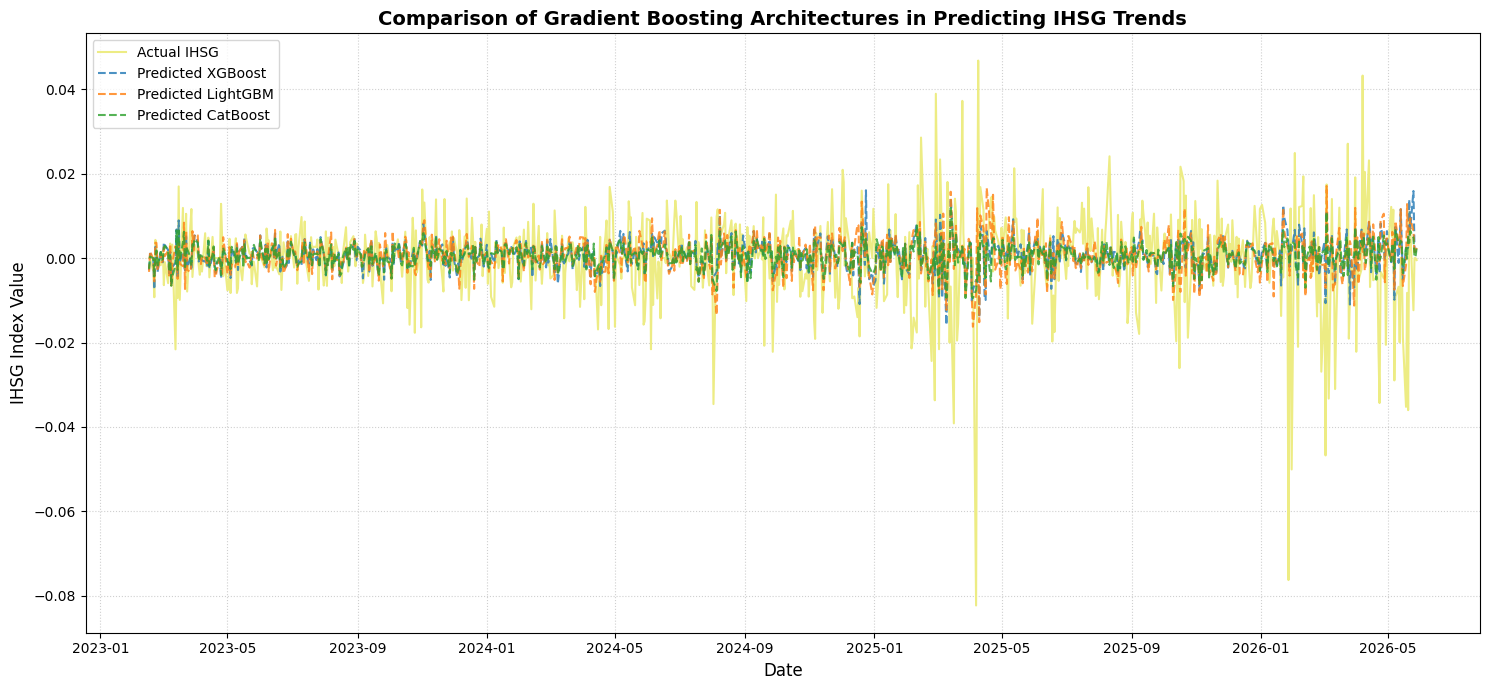

In [33]:
# %% [8] Visualisasi Hasil Prediksi vs Data Aktual
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test.values, label='Actual IHSG', color="#edec84", linewidth=1.5)

colors = {'XGBoost': '#1f77b4', 'LightGBM': '#ff7f0e', 'CatBoost': '#2ca02c'}
for name in best_models.keys():
    plt.plot(y_test.index, predictions[name], label=f'Predicted {name}', color=colors[name], alpha=0.8, linestyle='--')

plt.title('Comparison of Gradient Boosting Architectures in Predicting IHSG Trends', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('IHSG Index Value', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

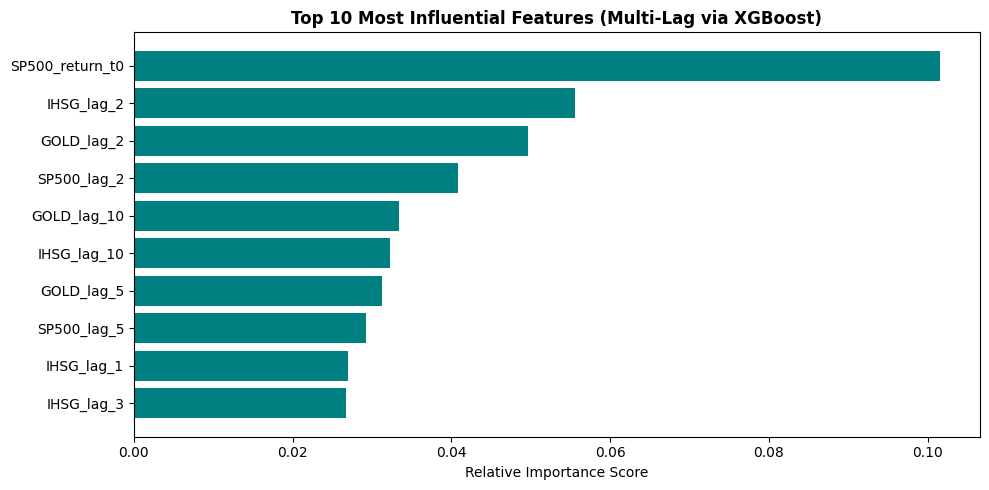

In [32]:
# %% [9] Feature Importance Analysis (Studi Kasus: XGBoost)
# Melihat fitur lag mana yang paling berpengaruh terhadap pergerakan IHSG
importances = best_models['XGBoost'].feature_importances_
df_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(df_importance['Feature'][::-1], df_importance['Importance'][::-1], color='teal')
plt.title('Top 10 Most Influential Features (Multi-Lag via XGBoost)', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

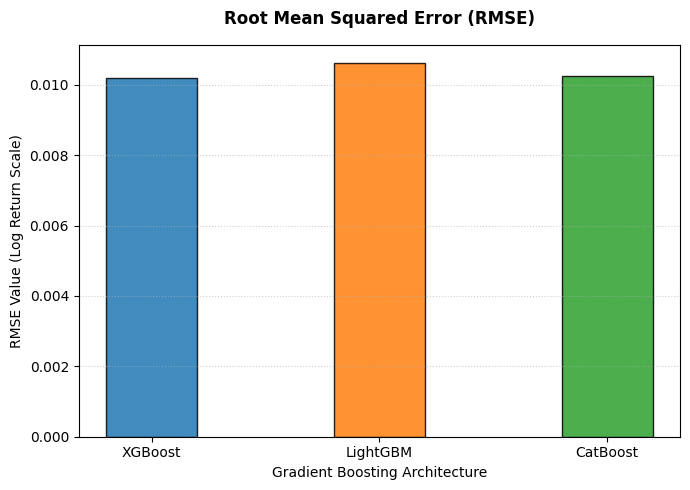

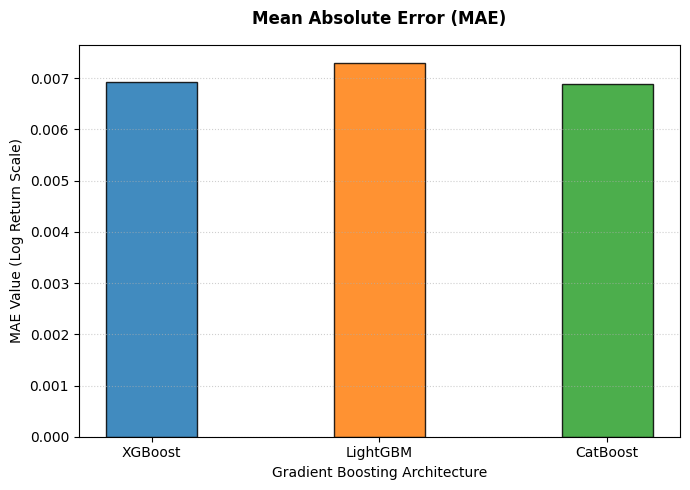

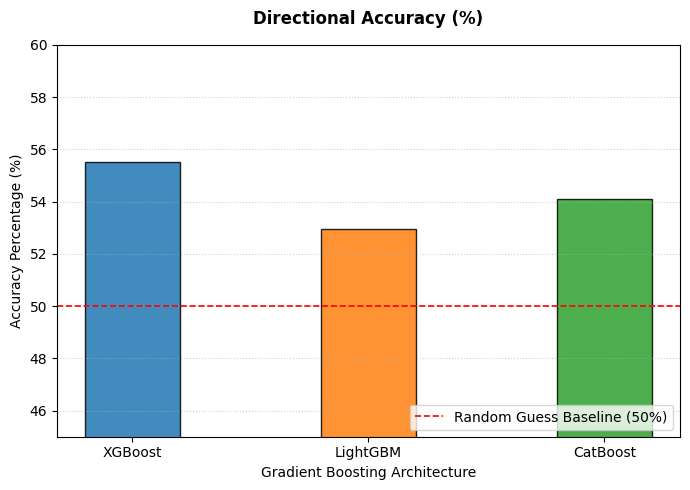

In [31]:
# %% [10.1] Visualisasi Perbandingan RMSE - (Lower is Better)
import matplotlib.pyplot as plt

models_list = df_results.index.tolist()
colors_map = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(7, 5))
bars = plt.bar(models_list, df_results['RMSE'], color=colors_map, alpha=0.85, edgecolor='black', width=0.4)

plt.title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('RMSE Value (Log Return Scale)', fontsize=10)
plt.xlabel('Gradient Boosting Architecture', fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# %% [10.2] Visualisasi Perbandingan MAE - (Lower is Better)
plt.figure(figsize=(7, 5))
bars = plt.bar(models_list, df_results['MAE'], color=colors_map, alpha=0.85, edgecolor='black', width=0.4)

plt.title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('MAE Value (Log Return Scale)', fontsize=10)
plt.xlabel('Gradient Boosting Architecture', fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# %% [10.3] Visualisasi Perbandingan Directional Accuracy (Higher is Better)
plt.figure(figsize=(7, 5))
bars = plt.bar(models_list, df_results['Dir_Accuracy (%)'], color=colors_map, alpha=0.85, edgecolor='black', width=0.4)

plt.title('Directional Accuracy (%)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Accuracy Percentage (%)', fontsize=10)
plt.xlabel('Gradient Boosting Architecture', fontsize=10)

# Fokus skala y di rentang krusial pergerakan pasar harian
plt.ylim(45, 60) 

# Garis acuan hoki/tebakan koin (Random Walk Baseline)
plt.axhline(50, color='red', linestyle='--', linewidth=1.2, label='Random Guess Baseline (50%)')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

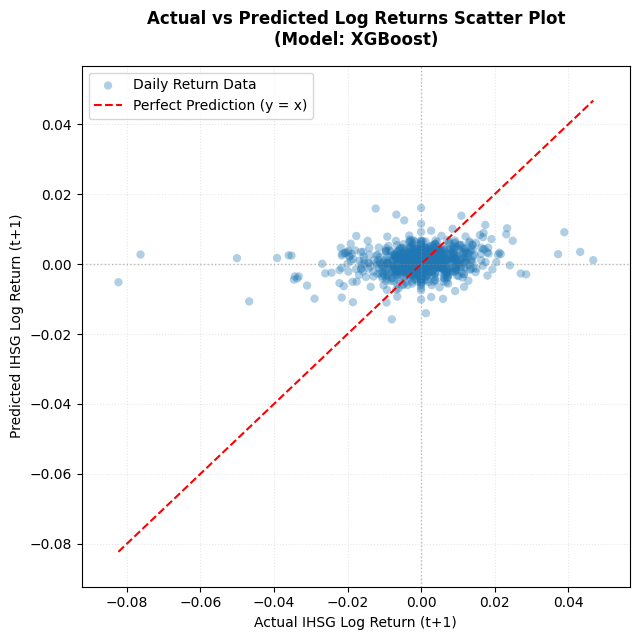

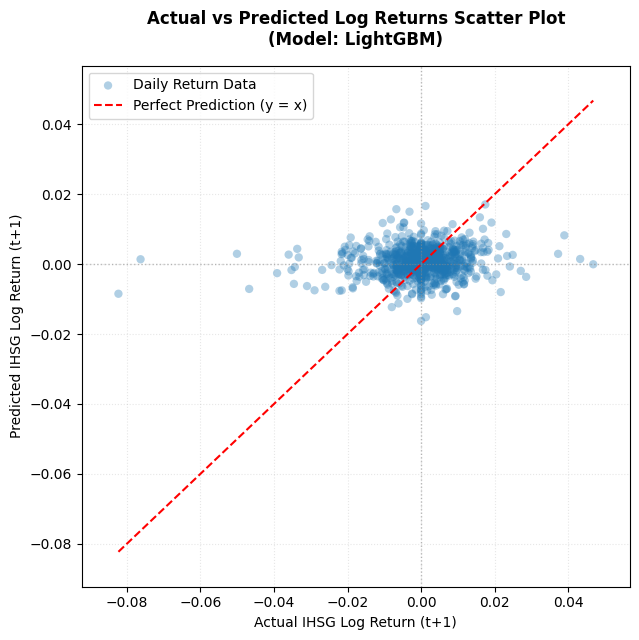

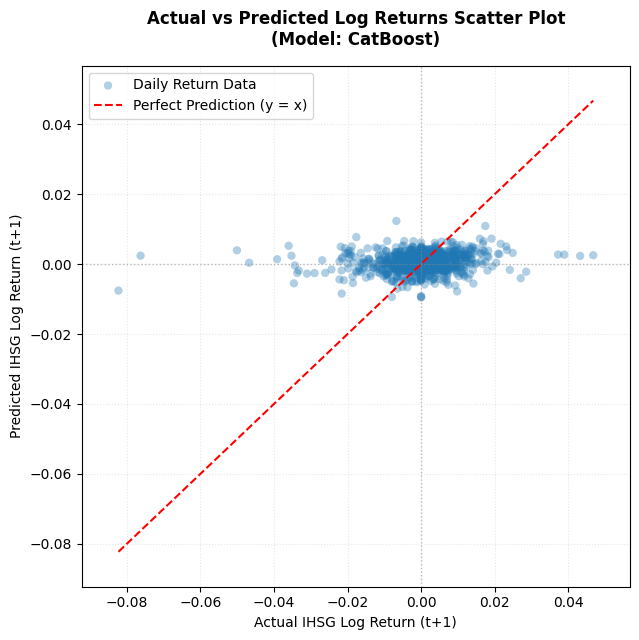

In [45]:
# %% [12.1] Scatter Plot Aktual vs Prediksi Teroptimasi - xgboost
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6.5, 6.5))

# Sumbu X (Aktual) vs Sumbu Y (Prediksi XGBoost)
plt.scatter(y_test, predictions['XGBoost'], color='#1f77b4', alpha=0.35, edgecolors='none', label='Daily Return Data')

# Garis ideal y = x
perfect_fit = np.linspace(min(y_test), max(y_test), 100)
plt.plot(perfect_fit, perfect_fit, color='red', linestyle='--', linewidth=1.5, label='Perfect Prediction (y = x)')

# TAMBAHAN: Garis bantu crosshair di (0,0) untuk mempertegas batas kuadran arah (Positif/Negatif)
plt.axhline(0, color='gray', linestyle=':', alpha=0.5, linewidth=1)
plt.axvline(0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.title('Actual vs Predicted Log Returns Scatter Plot\n(Model: XGBoost)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Actual IHSG Log Return (t+1)', fontsize=10)
plt.ylabel('Predicted IHSG Log Return (t+1)', fontsize=10)

# Menyamakan limit sumbu X dan Y agar aspek rasio 1:1 terlihat sempurna
plt.xlim(min(y_test)-0.01, max(y_test)+0.01)
plt.ylim(min(y_test)-0.01, max(y_test)+0.01)

plt.legend(loc='upper left')
plt.grid(linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

#######################################################################################
# %% [12.2] Scatter Plot Aktual vs Prediksi Teroptimasi -- LightGBM
plt.figure(figsize=(6.5, 6.5))

# Sumbu X (Aktual) vs Sumbu Y (Prediksi LightGBM)
plt.scatter(y_test, predictions['LightGBM'], color='#1f77b4', alpha=0.35, edgecolors='none', label='Daily Return Data')

# Garis ideal y = x
perfect_fit = np.linspace(min(y_test), max(y_test), 100)
plt.plot(perfect_fit, perfect_fit, color='red', linestyle='--', linewidth=1.5, label='Perfect Prediction (y = x)')

# TAMBAHAN: Garis bantu crosshair di (0,0) untuk mempertegas batas kuadran arah (Positif/Negatif)
plt.axhline(0, color='gray', linestyle=':', alpha=0.5, linewidth=1)
plt.axvline(0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.title('Actual vs Predicted Log Returns Scatter Plot\n(Model: LightGBM)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Actual IHSG Log Return (t+1)', fontsize=10)
plt.ylabel('Predicted IHSG Log Return (t+1)', fontsize=10)

# Menyamakan limit sumbu X dan Y agar aspek rasio 1:1 terlihat sempurna
plt.xlim(min(y_test)-0.01, max(y_test)+0.01)
plt.ylim(min(y_test)-0.01, max(y_test)+0.01)

plt.legend(loc='upper left')
plt.grid(linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

#######################################################################################
# %% [12.3] Scatter Plot Aktual vs Prediksi Teroptimasi -- CatBoost
plt.figure(figsize=(6.5, 6.5))

# Sumbu X (Aktual) vs Sumbu Y (Prediksi CatBoost)
plt.scatter(y_test, predictions['CatBoost'], color='#1f77b4', alpha=0.35, edgecolors='none', label='Daily Return Data')

# Garis ideal y = x
perfect_fit = np.linspace(min(y_test), max(y_test), 100)
plt.plot(perfect_fit, perfect_fit, color='red', linestyle='--', linewidth=1.5, label='Perfect Prediction (y = x)')

# TAMBAHAN: Garis bantu crosshair di (0,0) untuk mempertegas batas kuadran arah (Positif/Negatif)
plt.axhline(0, color='gray', linestyle=':', alpha=0.5, linewidth=1)
plt.axvline(0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.title('Actual vs Predicted Log Returns Scatter Plot\n(Model: CatBoost)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Actual IHSG Log Return (t+1)', fontsize=10)
plt.ylabel('Predicted IHSG Log Return (t+1)', fontsize=10)

# Menyamakan limit sumbu X dan Y agar aspek rasio 1:1 terlihat sempurna
plt.xlim(min(y_test)-0.01, max(y_test)+0.01)
plt.ylim(min(y_test)-0.01, max(y_test)+0.01)

plt.legend(loc='upper left')
plt.grid(linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

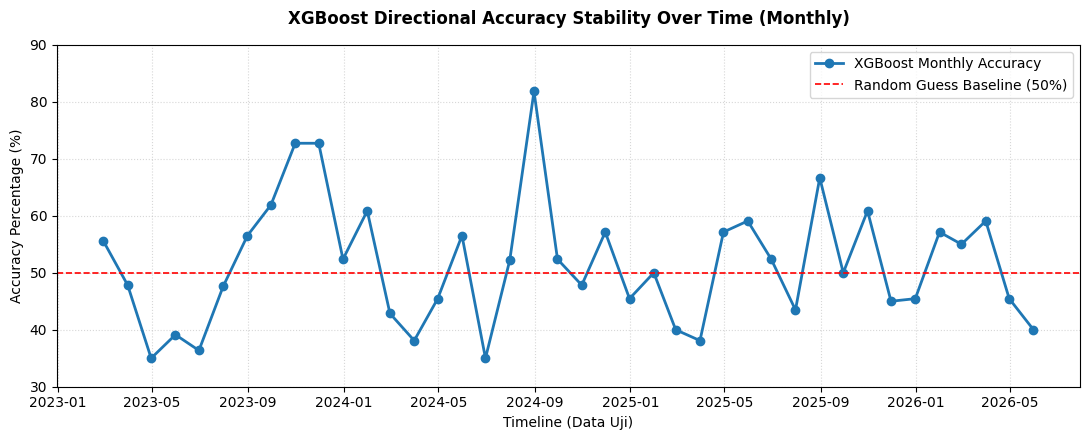

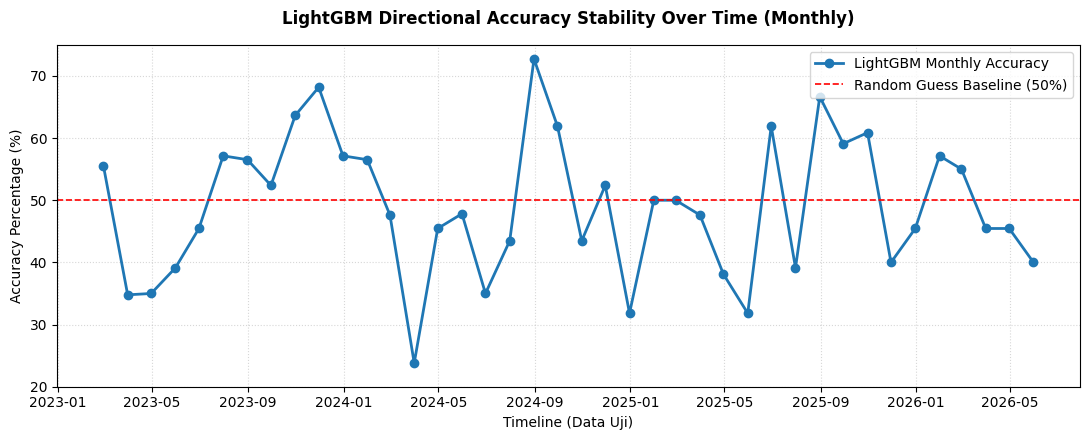

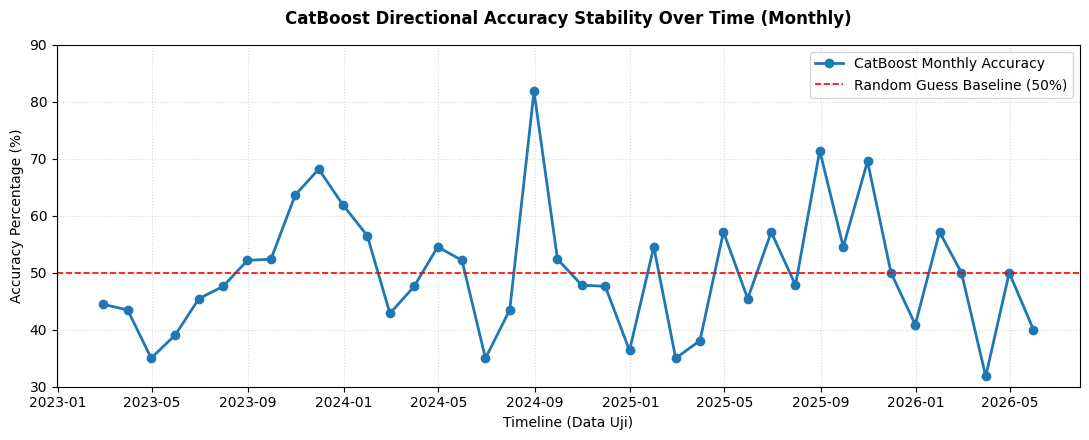

In [55]:
# %% [13.1] Visualisasi Stabilitas Akurasi Arah Bulanan (XGBoost)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Menghitung kebenaran prediksi arah harian (1 jika benar, 0 jika salah)
# Pastikan y_test memiliki index bertipe Datetime
df_stability = pd.DataFrame(index=y_test.index)
df_stability['Actual_Direction'] = np.sign(y_test)
df_stability['Pred_Direction'] = np.sign(predictions['XGBoost'])
df_stability['Is_Correct'] = (df_stability['Actual_Direction'] == df_stability['Pred_Direction']).astype(int)

# 2. Resample / Kelompokkan data per Bulan dan hitung rata-rata akurasinya
monthly_accuracy = df_stability['Is_Correct'].resample('ME').mean() * 100

# 3. Plot Grafik Garis Stabilitas Performa
plt.figure(figsize=(11, 4.5))
plt.plot(monthly_accuracy.index, monthly_accuracy.values, marker='o', color='#1f77b4', 
         linewidth=2, linestyle='-', label='XGBoost Monthly Accuracy')

# Garis acuan Tebakan Acak 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1.2, label='Random Guess Baseline (50%)')

# Mempercantik Tampilan Atribut Grafik
plt.title('XGBoost Directional Accuracy Stability Over Time (Monthly)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Timeline (Data Uji)', fontsize=10)
plt.ylabel('Accuracy Percentage (%)', fontsize=10)
plt.grid(linestyle=':', alpha=0.5)
plt.ylim(30, 90) # Rentang batas wajar fluktuasi akurasi bulanan saham
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

####################################################################
# %% [13.2] Visualisasi Stabilitas Akurasi Arah Bulanan (LightGBM)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Menghitung kebenaran prediksi arah harian (1 jika benar, 0 jika salah)
# Pastikan y_test memiliki index bertipe Datetime
df_stability = pd.DataFrame(index=y_test.index)
df_stability['Actual_Direction'] = np.sign(y_test)
df_stability['Pred_Direction'] = np.sign(predictions['LightGBM'])
df_stability['Is_Correct'] = (df_stability['Actual_Direction'] == df_stability['Pred_Direction']).astype(int)

# 2. Resample / Kelompokkan data per Bulan dan hitung rata-rata akurasinya
monthly_accuracy = df_stability['Is_Correct'].resample('ME').mean() * 100

# 3. Plot Grafik Garis Stabilitas Performa
plt.figure(figsize=(11, 4.5))
plt.plot(monthly_accuracy.index, monthly_accuracy.values, marker='o', color='#1f77b4', 
         linewidth=2, linestyle='-', label='LightGBM Monthly Accuracy')

# Garis acuan Tebakan Acak 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1.2, label='Random Guess Baseline (50%)')

# Mempercantik Tampilan Atribut Grafik
plt.title('LightGBM Directional Accuracy Stability Over Time (Monthly)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Timeline (Data Uji)', fontsize=10)
plt.ylabel('Accuracy Percentage (%)', fontsize=10)
plt.grid(linestyle=':', alpha=0.5)
plt.ylim(20, 75) # Rentang batas wajar fluktuasi akurasi bulanan saham
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

####################################################################
# %% [13.3] Visualisasi Stabilitas Akurasi Arah Bulanan (CatBoost)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Menghitung kebenaran prediksi arah harian (1 jika benar, 0 jika salah)
# Pastikan y_test memiliki index bertipe Datetime
df_stability = pd.DataFrame(index=y_test.index)
df_stability['Actual_Direction'] = np.sign(y_test)
df_stability['Pred_Direction'] = np.sign(predictions['CatBoost'])
df_stability['Is_Correct'] = (df_stability['Actual_Direction'] == df_stability['Pred_Direction']).astype(int)

# 2. Resample / Kelompokkan data per Bulan dan hitung rata-rata akurasinya
monthly_accuracy = df_stability['Is_Correct'].resample('ME').mean() * 100

# 3. Plot Grafik Garis Stabilitas Performa
plt.figure(figsize=(11, 4.5))
plt.plot(monthly_accuracy.index, monthly_accuracy.values, marker='o', color='#1f77b4', 
         linewidth=2, linestyle='-', label='CatBoost Monthly Accuracy')

# Garis acuan Tebakan Acak 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1.2, label='Random Guess Baseline (50%)')

# Mempercantik Tampilan Atribut Grafik
plt.title('CatBoost Directional Accuracy Stability Over Time (Monthly)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Timeline (Data Uji)', fontsize=10)
plt.ylabel('Accuracy Percentage (%)', fontsize=10)
plt.grid(linestyle=':', alpha=0.5)
plt.ylim(30,90) # Rentang batas wajar fluktuasi akurasi bulanan saham
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()